In [1]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import spacy
import re

/home/lmuyama/anaconda3/envs/nlp_env/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/lmuyama/anaconda3/envs/nlp_env/lib/python3.11/site-packages/torch/cuda/__init__.py:1036: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [2]:
# # Download necessary NLTK resources (only once)
# nltk.download("punkt")
# nltk.download("stopwords")
# nltk.download("wordnet")
# nltk.download("punkt_tab")

In [3]:
# Example text
text = "My name is Grace Birungi. I'm twelve years old. I love reading in the mornings."

print("Original Text:\n", text)

Original Text:
 My name is Grace Birungi. I'm twelve years old. I love reading in the mornings.


#### Normalization

In [4]:
#lowercasing, removing punctuation/numbers
normalized_text = re.sub(r'[^a-zA-Z\s]', '', text)   # remove punctuation/numbers
normalized_text = normalized_text.lower()            # lowercase
print(f"\nNormalized Text:\n {normalized_text}")


Normalized Text:
 my name is grace birungi im twelve years old i love reading in the mornings


#### Tokenization

In [5]:
tokens = word_tokenize(normalized_text)
print(f"\nTokens:\n {tokens}")


Tokens:
 ['my', 'name', 'is', 'grace', 'birungi', 'im', 'twelve', 'years', 'old', 'i', 'love', 'reading', 'in', 'the', 'mornings']


#### Stop Word Removal

In [6]:
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in tokens if w not in stop_words]
print(f"\nTokens after Stopword Removal:\n {filtered_tokens}")


Tokens after Stopword Removal:
 ['name', 'grace', 'birungi', 'im', 'twelve', 'years', 'old', 'love', 'reading', 'mornings']


#### Stemming

In [7]:
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(w) for w in filtered_tokens]
print(f"\nStemmed Tokens:\n {stemmed_tokens}")


Stemmed Tokens:
 ['name', 'grace', 'birungi', 'im', 'twelv', 'year', 'old', 'love', 'read', 'morn']


#### Lemmatization

In [8]:
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(w) for w in filtered_tokens]
print(f"\nLemmatized Tokens:\n {lemmatized_tokens}")


Lemmatized Tokens:
 ['name', 'grace', 'birungi', 'im', 'twelve', 'year', 'old', 'love', 'reading', 'morning']


In [9]:
# !python -m spacy download en_core_web_sm

In [10]:
# Lemmatization using the spaCy library
nlp = spacy.load("en_core_web_sm") # Load a small English model
doc = nlp(normalized_text)
spacy_lemmatized = [token.lemma_ for token in doc if not token.is_stop]
print(f"\nspaCy Lemmatized Tokens:\n {spacy_lemmatized}") # spaCy lemmatization uses POS tagging


spaCy Lemmatized Tokens:
 ['grace', 'birungi', 'm', 'year', 'old', 'love', 'read', 'morning']


#### POS Tagging

In [11]:
doc = nlp(text)
doc

My name is Grace Birungi. I'm twelve years old. I love reading in the mornings.

In [12]:
print("\nPOS Tagging:")
for token in doc:
    print(f"{token.text:12} {token.pos_:10} {token.tag_:5}")


POS Tagging:
My           PRON       PRP$ 
name         NOUN       NN   
is           AUX        VBZ  
Grace        PROPN      NNP  
Birungi      PROPN      NNP  
.            PUNCT      .    
I            PRON       PRP  
'm           AUX        VBP  
twelve       NUM        CD   
years        NOUN       NNS  
old          ADJ        JJ   
.            PUNCT      .    
I            PRON       PRP  
love         VERB       VBP  
reading      VERB       VBG  
in           ADP        IN   
the          DET        DT   
mornings     NOUN       NNS  
.            PUNCT      .    


#### Named Entity Recognition

In [13]:
print("\nNamed Entities:")
for ent in doc.ents:
    print(f"{ent.text:15} {ent.label_}")


Named Entities:
Grace Birungi   PERSON
twelve years old DATE


#### Dependency parsing

In [14]:
print("\nDependency Parsing:")
for token in doc:
    print(f"{token.text:12} {token.dep_:10} --> {token.head.text}")


Dependency Parsing:
My           poss       --> name
name         nsubj      --> is
is           ROOT       --> is
Grace        compound   --> Birungi
Birungi      attr       --> is
.            punct      --> is
I            nsubj      --> 'm
'm           ROOT       --> 'm
twelve       nummod     --> years
years        npadvmod   --> old
old          acomp      --> 'm
.            punct      --> 'm
I            nsubj      --> love
love         ROOT       --> love
reading      xcomp      --> love
in           prep       --> reading
the          det        --> mornings
mornings     pobj       --> in
.            punct      --> love


#### Bag-of-words

In [15]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [16]:
# Creates a document-term matrix of raw word counts.
corpus = [
    "My name is Grace Birungi",
    "I love reading in the mornings",
    "I love going to school",
    "My cousin's name is Anita"
]
vectorizer = CountVectorizer(stop_words="english")
bow_matrix = vectorizer.fit_transform(corpus)

print("\nBag of Words Vocabulary:")
print(vectorizer.get_feature_names_out())

print("\nBag of Words Matrix:")
print(bow_matrix.toarray())



Bag of Words Vocabulary:
['anita' 'birungi' 'cousin' 'going' 'grace' 'love' 'mornings' 'reading'
 'school']

Bag of Words Matrix:
[[0 1 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 1 1 0]
 [0 0 0 1 0 1 0 0 1]
 [1 0 1 0 0 0 0 0 0]]


#### TF-IDF (Term Frequency - Inverse Document Frequency)

In [17]:
# Weights terms by frequency, penalizing very common words.
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(corpus)

print("\nTF-IDF Vocabulary:")
print(tfidf.get_feature_names_out())

print("\nTF-IDF Matrix:")
print(tfidf_matrix.toarray())


TF-IDF Vocabulary:
['anita' 'birungi' 'cousin' 'going' 'grace' 'love' 'mornings' 'reading'
 'school']

TF-IDF Matrix:
[[0.         0.70710678 0.         0.         0.70710678 0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.48693426
  0.61761437 0.61761437 0.        ]
 [0.         0.         0.         0.61761437 0.         0.48693426
  0.         0.         0.61761437]
 [0.70710678 0.         0.70710678 0.         0.         0.
  0.         0.         0.        ]]


#### N-Grams

In [18]:
print("\nN-grams (bigrams and trigrams):")

vectorizer = CountVectorizer(ngram_range=(2, 3))  # bigrams + trigrams
X = vectorizer.fit_transform(corpus)
print("N-gram Vocabulary:\n", vectorizer.get_feature_names_out())
print("N-gram Matrix:\n", X.toarray())


N-grams (bigrams and trigrams):
N-gram Vocabulary:
 ['cousin name' 'cousin name is' 'going to' 'going to school'
 'grace birungi' 'in the' 'in the mornings' 'is anita' 'is grace'
 'is grace birungi' 'love going' 'love going to' 'love reading'
 'love reading in' 'my cousin' 'my cousin name' 'my name' 'my name is'
 'name is' 'name is anita' 'name is grace' 'reading in' 'reading in the'
 'the mornings' 'to school']
N-gram Matrix:
 [[0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0]
 [0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0]
 [0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0]]


#### Homework: Word embeddings

#### A simple NLP task

In [19]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import pandas as pd

In [20]:
data = pd.read_csv("data/IMDB Dataset.csv")
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [21]:
data.iloc[10]["review"]

'Phil the Alien is one of those quirky films where the humour is based around the oddness of everything rather than actual punchlines.<br /><br />At first it was very odd and pretty funny but as the movie progressed I didn\'t find the jokes or oddness funny anymore.<br /><br />Its a low budget film (thats never a problem in itself), there were some pretty interesting characters, but eventually I just lost interest.<br /><br />I imagine this film would appeal to a stoner who is currently partaking.<br /><br />For something similar but better try "Brother from another planet"'

In [22]:
X = data["review"]
y = data["sentiment"]
X.shape, y.shape

((50000,), (50000,))

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [24]:
model = make_pipeline(TfidfVectorizer(stop_words="english"), LogisticRegression())
model.fit(X_train, y_train)

,steps,"[('tfidfvectorizer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [25]:
y_pred = model.predict(X_test)

In [26]:
y_pred[:5]

array(['negative', 'positive', 'negative', 'positive', 'negative'],
      dtype=object)

In [27]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[6524  887]
 [ 706 6883]]


In [28]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      7411
    positive       0.89      0.91      0.90      7589

    accuracy                           0.89     15000
   macro avg       0.89      0.89      0.89     15000
weighted avg       0.89      0.89      0.89     15000



In [29]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8938

#### Using a neural network

In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.datasets import imdb
import numpy as np

2025-09-04 10:57:22.158341: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-04 10:57:22.165520: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756972642.172987  147139 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756972642.175143  147139 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756972642.181086  147139 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [31]:
num_words=10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words) # limits the vocabulary to the top 10,000 most frequent words

In [32]:
x_train[:2]

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [33]:
# data preprocessing
maxlen = 200  # cut reviews after 200 words
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

In [34]:
x_train[:5]

array([[   5,   25,  100,   43,  838,  112,   50,  670,    2,    9,   35,
         480,  284,    5,  150,    4,  172,  112,  167,    2,  336,  385,
          39,    4,  172, 4536, 1111,   17,  546,   38,   13,  447,    4,
         192,   50,   16,    6,  147, 2025,   19,   14,   22,    4, 1920,
        4613,  469,    4,   22,   71,   87,   12,   16,   43,  530,   38,
          76,   15,   13, 1247,    4,   22,   17,  515,   17,   12,   16,
         626,   18,    2,    5,   62,  386,   12,    8,  316,    8,  106,
           5,    4, 2223, 5244,   16,  480,   66, 3785,   33,    4,  130,
          12,   16,   38,  619,    5,   25,  124,   51,   36,  135,   48,
          25, 1415,   33,    6,   22,   12,  215,   28,   77,   52,    5,
          14,  407,   16,   82,    2,    8,    4,  107,  117, 5952,   15,
         256,    4,    2,    7, 3766,    5,  723,   36,   71,   43,  530,
         476,   26,  400,  317,   46,    7,    4,    2, 1029,   13,  104,
          88,    4,  381,   15,  297, 

In [35]:
# building a simple FFNN
model = keras.Sequential([
    layers.Embedding(input_dim=num_words, output_dim=64),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")  # binary classification
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

2025-09-04 10:57:29.211517: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-09-04 10:57:29.211550: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-09-04 10:57:29.211554: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: PL1207-PRO.paris.inria.fr
2025-09-04 10:57:29.211560: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] hostname: PL1207-PRO.paris.inria.fr
2025-09-04 10:57:29.211688: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:197] libcuda reported version is: 535.183.1
2025-09-04 10:57:29.211708: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:201] kernel 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
# training the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=512,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6181 - loss: 0.6808 - val_accuracy: 0.7310 - val_loss: 0.6495
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7567 - loss: 0.5948 - val_accuracy: 0.7952 - val_loss: 0.5226
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8246 - loss: 0.4550 - val_accuracy: 0.8150 - val_loss: 0.4186
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8562 - loss: 0.3612 - val_accuracy: 0.8170 - val_loss: 0.3993
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8724 - loss: 0.3159 - val_accuracy: 0.8666 - val_loss: 0.3249


In [37]:
# Model evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")


✅ Test Accuracy: 0.8638


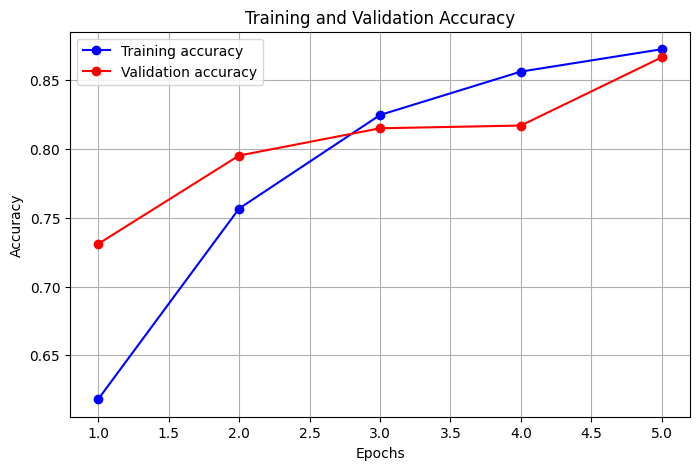

In [38]:
# plotting training and validation accuracy
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, acc, "bo-", label="Training accuracy")
plt.plot(epochs, val_acc, "ro-", label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {v+3: k for k, v in word_index.items()}  # shift by 3 (special tokens)
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"

def decode_review(sequence):
    return " ".join([reverse_word_index.get(i, "?") for i in sequence])

sample = x_test[0]
# print("\nReview:", decode_review(sample))
print("True label:", "Positive" if y_test[0] == 1 else "Negative")
print("Predicted:", "Positive" if model.predict(sample.reshape(1, -1))[0][0] > 0.5 else "Negative")


True label: Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted: Negative


#### Using an LSTM

In [40]:
lstm_model = keras.Sequential([
    layers.Embedding(input_dim=num_words, output_dim=64), # embeds words into vectors
    layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(1, activation="sigmoid") # dense output layer for binary classification
])

lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
lstm_history = lstm_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# 4. Evaluate on test set
# -----------------------------
test_loss, test_acc = lstm_model.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.7358 - loss: 0.5417 - val_accuracy: 0.8464 - val_loss: 0.3700
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8593 - loss: 0.3526 - val_accuracy: 0.8564 - val_loss: 0.3437
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8836 - loss: 0.2958 - val_accuracy: 0.8220 - val_loss: 0.3935
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.8957 - loss: 0.2730 - val_accuracy: 0.7872 - val_loss: 0.4422
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.9040 - loss: 0.2475 - val_accuracy: 0.8342 - val_loss: 0.4098

✅ Test Accuracy: 0.8364


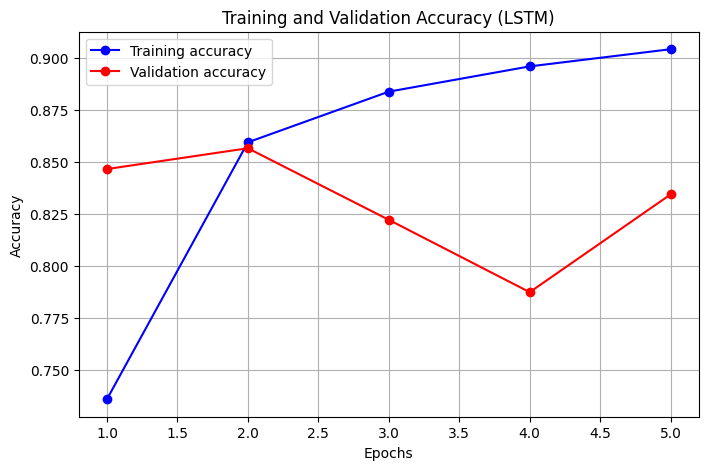

In [42]:
lstm_acc = lstm_history.history['accuracy']
lstm_val_acc = lstm_history.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, lstm_acc, "bo-", label="Training accuracy")
plt.plot(epochs, lstm_val_acc, "ro-", label="Validation accuracy")
plt.title("Training and Validation Accuracy (LSTM)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#### Homework: Using a transformer